<a href="https://colab.research.google.com/github/SalmaLilad/UCSC-PYaR-Research/blob/main/programs/6-Velocity%20Dispersion%20Activity.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In this activity, you are going to be making dispersion maps of Andromeda for the 3 different types of stars you learned about in week 1: Main Sequence (MS) stars, Red Giant Branch (RGB) stars, and Asymptotic Giant Branch (AGB) stars. We want to understand what these three maps tell us about the history of the Andromeda galaxy.

As usual, begin by running the first cell to import all necessary functions from numpy and matplotlib:

In [ ]:
# This clones your repo and sets the directory so the notebooks can find the 'data' folder
import os

repo_url = "https://github.com/SalmaLilad/UCSC-PYaR-Research"
repo_name = "UCSC-PYaR-Research"

#if not os.path.exists(repo_name):
    #!git clone {repo_url}

# Move the working directory into the 'programs' folder so file paths like '../data/' work
os.chdir(f"{repo_name}/programs")

print(f"Current working directory: {os.getcwd()}")

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

Here, we are introducing the function "show_map." You may recognize it from last week's activity about simulated disks. Run the below cell--you do not need to make any edits here.

In [2]:
def show_map(xi, eta, quantity, label, fileName):
    ax = plt.axes(aspect = 'equal')
    ax.set_xlabel('xi (kpc)')
    ax.set_ylabel('eta (kpc)')
    ax.set_title('Dispersion of Real Data')
    tt = ax.scatter(xi, eta, c = quantity, edgecolors = 'none', s = 2, vmin=40., vmax=160.)
    ax.set_xlim(1, 0)
    plt.colorbar(tt, label='Velocity Dispersion (km/s)')
    plt.savefig(fileName)

This next function is where we are calculating the dispersion. Fill in the incomplete lines of code below. To search for math help in python, Google "numpy" followed by the thing you want to do.

In [11]:
def get_dispersion(x, z, v, circleSize=100./3600.):
    #initialize dispersion to all zeros
    dispersion = np.zeros(len(x))

    #Loop over all items in list
    for i in range(len(x)):
        #get coordinates of the item of interest
        thisX = x[i]
        thisZ = z[i]

        #calculate array of distances to this star
        dist = np.sqrt((x - thisX)**2 + (z - thisZ)**2)

        #pick out stars that are closer than circleSize to the star
        keep = dist < circleSize

        #calculate the velocity dispersion of those stars; assign to the ith element
        #of the array "dispersion"
        dispersion[i] = np.std(v[keep]) #dispersion = standard deviation

    return dispersion

The following lines of code are going to call the above two functions to generate the plots we are interested in. It is going to read in the catalogs that you created in the first activity (the CMD activity). If you do not have copies of these catalogs in your "data" folder, be sure to download them from Schoology.


## Once you've generated your figure, play with the parameter "circleSize" in get_dispersion.
What happens when you make circleSize=100./3600.? What about 3600./3600.? Work with your partner to try to explain the differences between the two plots. Change the value of circleSize=300./3600. before you continue.

0.0
287.6919294640536
55.65553096962411


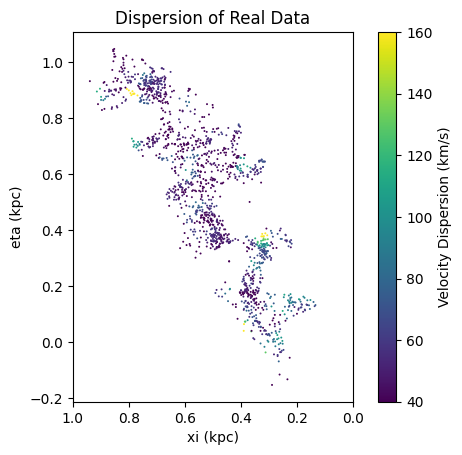

In [12]:
#Read data
xi, eta, v = np.loadtxt('../data/MScatalog.txt', unpack = True, usecols = (2, 3, 6))

##IMPORTANT: THESE NEXT FEW LINES ACCOUNT FOR A BUG IN THE CATALOGS.
##MAKE SURE YOU INCLUDE THESE LINES IN YOUR AGB AND RGB CODES.
#___________________________
keep=(np.abs(v) < 1000.)
xi=xi[keep]
eta=eta[keep]
v=v[keep]
#___________________________

#Calculate dispersion
ms_sigma = get_dispersion(xi, eta, v)
print(np.min(ms_sigma)) 
print(np.max(ms_sigma)) 
print(np.mean(ms_sigma))

#Generate velocity map
show_map(xi, eta, ms_sigma, 'Velocity dispersion (km/s)', '../plots/MS_dispersion_map.png')

3.6940000000000026
227.49670662334682
108.65861527302478


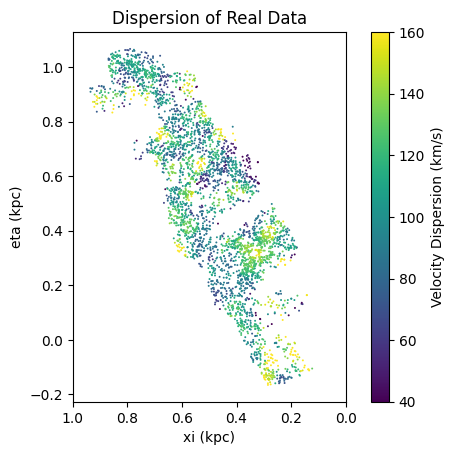

In [13]:
xi, eta, v = np.loadtxt('../data/AGBcatalog.txt', unpack = True, usecols = (2, 3, 6))

##IMPORTANT: THESE NEXT FEW LINES ACCOUNT FOR A BUG IN THE CATALOGS.
##MAKE SURE YOU INCLUDE THESE LINES IN YOUR AGB AND RGB CODES.
#___________________________
keep=(np.abs(v) < 1000.)
xi=xi[keep]
eta=eta[keep]
v=v[keep]
#___________________________

#Calculate dispersion
agb_sigma = get_dispersion(xi, eta, v)
print(np.min(agb_sigma)) 
print(np.max(agb_sigma)) 
print(np.mean(agb_sigma))

#Generate velocity map
show_map(xi, eta, agb_sigma, 'Velocity dispersion (km/s)', '../plots/AGB_dispersion_map.png')

36.8134400896517
227.14491524477396
102.79187615787912


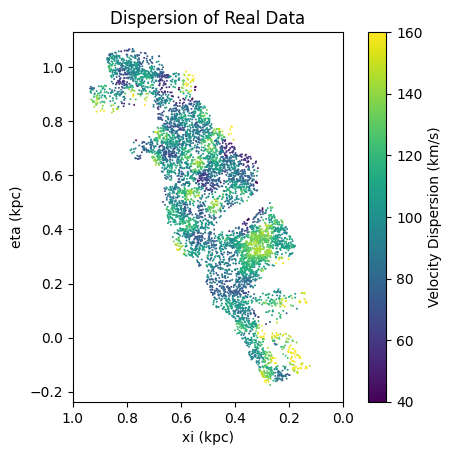

In [14]:
xi, eta, v = np.loadtxt('../data/RGBcatalog.txt', unpack = True, usecols = (2, 3, 6))

##IMPORTANT: THESE NEXT FEW LINES ACCOUNT FOR A BUG IN THE CATALOGS.
##MAKE SURE YOU INCLUDE THESE LINES IN YOUR AGB AND RGB CODES.
#___________________________
keep=(np.abs(v) < 1000.)
xi=xi[keep]
eta=eta[keep]
v=v[keep]
#___________________________

#Calculate dispersion
rgb_sigma = get_dispersion(xi, eta, v)
print(np.min(rgb_sigma)) 
print(np.max(rgb_sigma)) 
print(np.mean(rgb_sigma))

#Generate velocity map
show_map(xi, eta, rgb_sigma, 'Velocity dispersion (km/s)', '../plots/RGB_dispersion_map.png')

After you’ve made all 3 maps, open up all 3 plots together (they are saved in your plots foloder). Look at them next to each other. What do you observe about these 3 maps? What do they have in common, and how are they different?

Similar: They all share the same butterfly shape, and the AGB & RGB maps have similar schemes of velocity's proportional to their etas & xis
Different: They all have different amounts of data on them, and the MS has way more lower velocity dispersions across the board compared to AGB & RGB's

Now, plot histograms for the velocity dispersions of the 3 types of stars. If you aren’t sure what a histogram is, begin by Googling that! Hint: to search for plotting help in python, Google “matplotlib” followed by the thing you want to do (for example, if I wanted to make a plot of a line, I would Google “matplotlib plot line”).

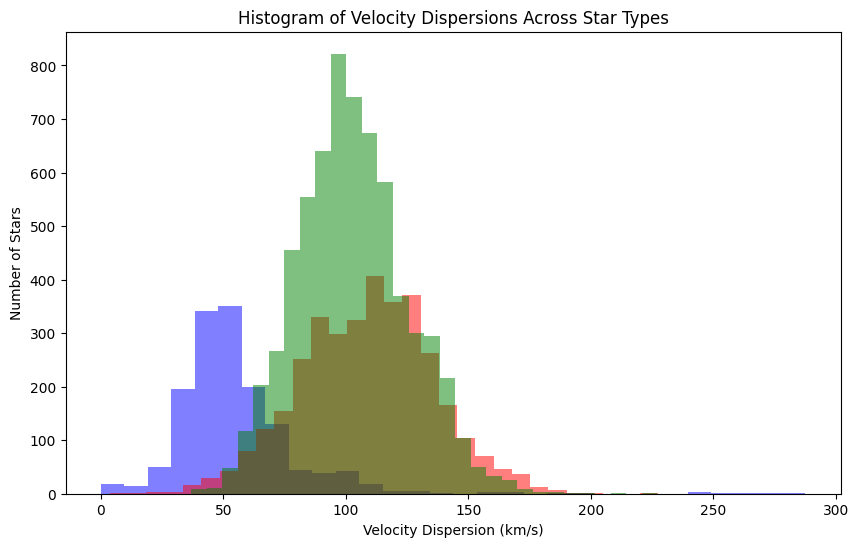

In [27]:
#Put your histogram plotting code here!

plt.figure(figsize=(10,6))

plt.hist(ms_sigma, bins=30, alpha=0.5, label= 'Main Sequence', color= 'blue')
plt.hist(agb_sigma, bins=30, alpha=0.5, label= 'AGB Stars', color= 'red')
plt.hist(rgb_sigma, bins=30, alpha=0.5, label= 'RGB Stars', color='green')

plt.title(("Histogram of Velocity Dispersions Across Star Types"))
plt.xlabel("Velocity Dispersion (km/s)")
plt.ylabel("Number of Stars")

plt.show()

Finally, compute the median velocity dispersion for each of the 3 age groups. Don't be afraid to use Google!

In [28]:
#Compute and print the median values here!
ms_median = np.median(ms_sigma)
agb_median = np.median(agb_sigma)
rgb_median = np.median(rgb_sigma)

#{float_ex:.2f} rounds floats to 2 decimal places
print(f"Median: {ms_median:.2f}")
print(f"Median: {agb_median:.2f}")
print(f"Median: {rgb_median:.2f}")

Median: 51.87
Median: 110.10
Median: 101.31


Do your median values and histograms agree with your interpretation of the 3 maps?

Yes they do, as the majority of the stars on the graph for each star type are in the dispersion ranges where the medians (middle values) make sense to be in.